In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [3]:
# Загрузка данных
X = pd.read_excel('X_data.xlsx')
df_y = pd.read_excel('Y_data.xlsx')

# вычисление медианного значения SI
median_SI = df_y['SI'].median()

# создание бинарной целевой переменной на основе медианного значения SI
y = (df_y['SI'] > median_SI).astype(int)

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [4]:
# Decision Tree Classifier для предсказания исходного SI > медианного значения на основе молекулярных дескрипторов

# Создание и обучение модели
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

clf.fit(X_train, y_train)

# Предсказывание на тестовой выборке
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Decision Tree:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Decision Tree:
              precision    recall  f1-score   support

           0       0.60      0.84      0.70       100
           1       0.74      0.45      0.56       100

    accuracy                           0.65       200
   macro avg       0.67      0.65      0.63       200
weighted avg       0.67      0.65      0.63       200

Матрица ошибок:
[[84 16]
 [55 45]]
Точность модели: 0.65
ROC AUC модели: 0.68


##### Вывод:

Для первичной оценки возможности разделения соединений по уровню SI (Selectivity Index) была использована модель DecisionTreeClassifier. Одиночное дерево решений показало умеренное качество классификации (Accuracy ≈ 0.65, ROC-AUC ≈ 0.68). Модель значительно лучше распознавала класс 0 (recall ≈ 0.84), чем класс 1 (recall ≈ 0.45), что указывает на выраженное смещение модели в сторону отрицательного класса. Матрица ошибок также показывает большое количество ложноотрицательных предсказаний для класса 1. 

Полученные результаты свидетельствуют о том, что одиночное дерево решений способно выявлять часть закономерностей между молекулярными дескрипторами и значениями SI, однако остаётся недостаточно устойчивой моделью для данной QSAR-задачи и склонно к переобучению. Более низкое качество распознавания класса 1 может указывать на более сложную структуру зависимости SI от молекулярных дескрипторов по сравнению с задачами классификации IC50 и CC50. 

Для повышения устойчивости модели и улучшения качества классификации далее построим модели на основе ансамблевых методов и более сложные нелинейные модели машинного обучения.


In [5]:
# Настройка гиперпараметров для Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 3, 5, 7, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False]
}

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

# Вывод лучших параметров и результатов кросс-валидации
print("Best params:", search.best_params_)
print("Best CV ROC-AUC:", search.best_score_)

# Получение лучшей модели
best_rf = search.best_estimator_

# Предсказывание на тестовой выборке
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Random Forest:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': False}
Best CV ROC-AUC: 0.7569238528481013
Отчет о классификации Random Forest:
              precision    recall  f1-score   support

           0       0.63      0.70      0.66       100
           1       0.66      0.59      0.62       100

    accuracy                           0.65       200
   macro avg       0.65      0.65      0.64       200
weighted avg       0.65      0.65      0.64       200

Матрица ошибок:
[[70 30]
 [41 59]]
Точность модели: 0.65
ROC AUC модели: 0.69


##### Вывод:

Для повышения устойчивости модели и уменьшения переобучения был использован RandomForestClassifier, представляющий собой ансамбль деревьев решений. Подбор гиперпараметров осуществлялся с помощью RandomizedSearchCV и кросс-валидации (cv=5) с использованием метрики ROC-AUC.

По сравнению с одиночным деревом решений RandomForestClassifier не продемонстрировал существенного улучшения качества классификации SI (Accuracy ≈ 0.65, ROC-AUC ≈ 0.69).

Полученные результаты могут свидетельствовать о более сложной природе зависимости SI от молекулярных дескрипторов по сравнению с задачами классификации IC50 и CC50. Поскольку SI представляет собой производную характеристику, зависящую одновременно от IC50 и CC50, задача его классификации может содержать более высокий уровень шума и менее выраженные закономерности в пространстве молекулярных дескрипторов.

<Axes: title={'center': 'Важность признаков после обучения случайного леса'}, ylabel='Feature'>

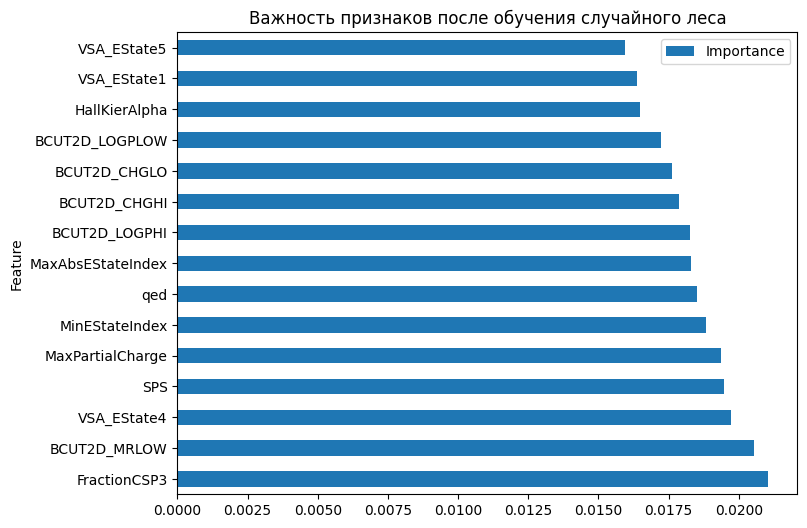

In [6]:
# визуализация важности признаков после обучения случайного леса
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения случайного леса'
)

Анализ важности признаков RandomForestClassifier для классификации SI показал, что наибольший вклад в разделение классов вносят дескрипторы, характеризующие электронные свойства, распределение зарядов и физико-химические характеристики молекул. 

Среди наиболее значимых признаков модель выделила FractionCSP3, BCUT2D_MRLOW, VSA_EState4, SPS, MaxPartialCharge, MinEStateIndex и qed. Это указывает на важную роль пространственной структуры молекулы, распределения электронной плотности, частичных зарядов и общей drug-likeness характеристики в определении значений SI.

Высокая важность дескрипторов семейств BCUT2D, VSA_EState и HallKierAlpha также свидетельствует о значительном влиянии топологических и электронных свойств молекулы на селективность соединений.

Полученные результаты подтверждают, что SI определяется сложной совокупностью структурных, электронных и физико-химических характеристик молекул. При этом отсутствие выраженного улучшения качества классификации по сравнению с задачами IC50 и CC50 может указывать на более сложную и шумную природу зависимости SI от молекулярных дескрипторов.

In [7]:
# Логистическая регрессия для предсказания исходного SI> медианного значения на основе молекулярных дескрипторов
# параметры модели: L1-регуляризация, solver='liblinear', max_iter=10000, random_state=42

model_l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    max_iter=10000,
    random_state=42
)

model_l1.fit(X_train, y_train)

# Предсказывание на тестовой выборке
y_pred = model_l1.predict(X_test)
y_prob = model_l1.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Logistic Regression с L1-регуляризацией:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Logistic Regression с L1-регуляризацией:
              precision    recall  f1-score   support

           0       0.63      0.63      0.63       100
           1       0.63      0.63      0.63       100

    accuracy                           0.63       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.63      0.63       200

Матрица ошибок:
[[63 37]
 [37 63]]
Точность модели: 0.63
ROC AUC модели: 0.67


In [14]:
# Логистическая регрессия для предсказания исходного SI > медианного значения на основе молекулярных дескрипторов
# параметры модели: L2-регуляризация, solver='liblinear', max_iter=50000, random_state=42

# cоздание и обучение модели
model_l2 = LogisticRegression(
    penalty='l2',
    solver='liblinear',
    max_iter=50000,
    random_state=42
)

model_l2.fit(X_train, y_train)

# предсказывание на тестовой выборке
y_pred = model_l2.predict(X_test)
y_prob = model_l2.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации Logistic Regression с L2-регуляризацией:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации Logistic Regression с L2-регуляризацией:
              precision    recall  f1-score   support

           0       0.62      0.63      0.63       100
           1       0.63      0.62      0.62       100

    accuracy                           0.62       200
   macro avg       0.63      0.62      0.62       200
weighted avg       0.63      0.62      0.62       200

Матрица ошибок:
[[63 37]
 [38 62]]
Точность модели: 0.62
ROC AUC модели: 0.67


##### Вывод:

Модель LogisticRegression с L1-регуляризацией показала немного более высокое качество классификации SI (Accuracy ≈ 0.63, ROC-AUC ≈ 0.67) по сравнению с моделью с L2-регуляризацией. 

Использование L1-регуляризации позволило уменьшить влияние мультиколлинеарности и автоматически выполнить отбор наиболее информативных молекулярных дескрипторов, что особенно важно при работе с высокоразмерными QSAR-данными. 

В отличие от задачи классификации SI > 8, модель с L2-регуляризацией в данном случае не продемонстрировала полной деградации качества и обеспечила сопоставимые результаты классификации. Это может быть связано с более сбалансированным разделением классов при использовании медианного значения SI в качестве порога.

Полученные результаты подтверждают, что для задачи классификации SI отбор признаков играет важную роль, однако различия между L1- и L2-регуляризацией при классификации относительно медианного значения SI оказались менее выраженными. 

In [10]:
# CatBoost Classifier для предсказания исходного SI > медианного значения на основе молекулярных дескрипторов

# Создание и обучение модели
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_state=42,
    verbose=0
)

model.fit(X_train, y_train)

# Предсказывание на тестовой выборке
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации CatBoost:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации CatBoost:
              precision    recall  f1-score   support

           0       0.63      0.63      0.63       100
           1       0.63      0.63      0.63       100

    accuracy                           0.63       200
   macro avg       0.63      0.63      0.63       200
weighted avg       0.63      0.63      0.63       200

Матрица ошибок:
[[63 37]
 [37 63]]
Точность модели: 0.63
ROC AUC модели: 0.67


##### Вывод:

Модель CatBoostClassifier не продемонстрировала существенного улучшения качества классификации SI по сравнению с более простыми моделями (Accuracy ≈ 0.63, ROC-AUC ≈ 0.67). Несмотря на использование boosting-подхода, модель показала лишь умеренное качество разделения классов, что может свидетельствовать о слабой выраженности закономерностей между молекулярными дескрипторами и значениями SI.

Полученные результаты позволяют предположить, что задача классификации SI является более сложной по сравнению с классификацией IC50 и CC50, поскольку SI представляет собой производную характеристику, зависящую одновременно от биологической активности и токсичности соединений.

<Axes: title={'center': 'Важность признаков после обучения CatBoost'}, ylabel='Feature'>

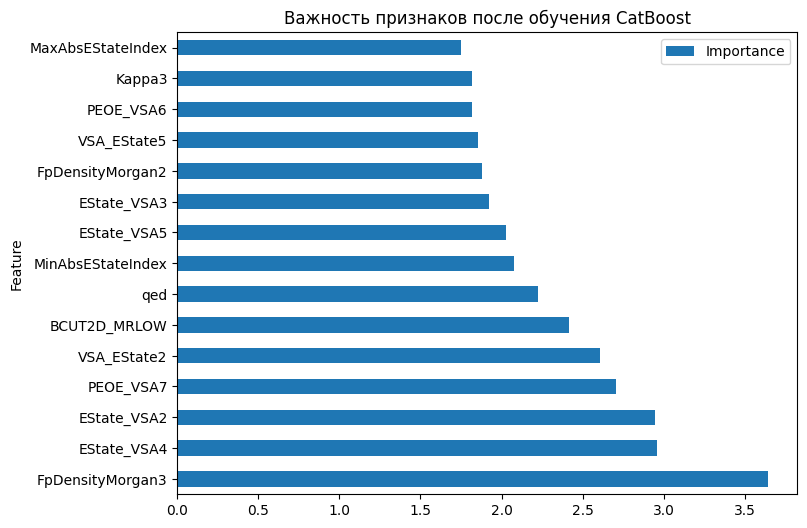

In [11]:
# визуализация важности признаков после обучения CatBoost
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

importance_df.head(15).plot.barh(
    x='Feature',
    y='Importance',
    figsize=(8,6),
    title='Важность признаков после обучения CatBoost'
)

Анализ важности признаков CatBoostClassifier для классификации SI показал, что наибольший вклад в разделение классов вносят дескрипторы, характеризующие электронные свойства, топологию и физико-химические характеристики молекул.

Среди наиболее значимых признаков модель выделила FpDensityMorgan3, EState_VSA4, EState_VSA2, PEOE_VSA7, VSA_EState2, BCUT2D_MRLOW и qed. Это указывает на важную роль распределения электронной плотности, топологических характеристик молекулы, липофильности и drug-likeness свойств в определении селективности соединений.

Высокая важность дескрипторов семейств EState_VSA, PEOE_VSA и BCUT2D также свидетельствует о значительном влиянии электронных и поверхностных свойств молекул на значения SI.

Полученные результаты хорошо согласуются с выводами RandomForestClassifier и подтверждают, что селективность соединений определяется сложной совокупностью структурных, электронных и физико-химических характеристик молекул. 

При этом умеренное качество классификации даже для boosting-модели CatBoostClassifier может указывать на более сложную и шумную природу зависимости SI от молекулярных дескрипторов по сравнению с задачами классификации IC50 и CC50.

In [12]:
# SVM Classifier  для предсказания исходного SI > медианного значения на основе молекулярных дескрипторов

# стандартизация данных
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Создание и обучение модели
model = SVC(kernel='rbf', C=1, gamma='scale')
model.fit(X_train, y_train)

# Предсказание на тестовой выборке
y_pred = model.predict(X_test)
y_prob = model.decision_function(X_test)

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации SVM:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Отчет о классификации SVM:
              precision    recall  f1-score   support

           0       0.67      0.74      0.70       100
           1       0.71      0.63      0.67       100

    accuracy                           0.69       200
   macro avg       0.69      0.69      0.68       200
weighted avg       0.69      0.69      0.68       200

Матрица ошибок:
[[74 26]
 [37 63]]
Точность модели: 0.69
ROC AUC модели: 0.75


In [13]:
# Настройка гиперпараметров для SVM Classifier с использованием GridSearchCV

# Создание пайплайна для стандартизации данных и обучения модели SVM
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', probability=True, random_state=42))
])

# Определение сетки гиперпараметров для поиска
param_grid = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.1, 0.01, 0.001]
}

# Настройка GridSearchCV для поиска лучших гиперпараметров
grid = GridSearchCV(
    pipe,
    param_grid,
    scoring='roc_auc',
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Обучение модели с использованием GridSearchCV
grid.fit(X_train, y_train)

# Вывод лучших параметров и результатов кросс-валидации
print("Best params:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

# Получение лучшей модели
best_svm = grid.best_estimator_

# Предсказывание на тестовой выборке с использованием лучшей модели
y_pred = best_svm.predict(X_test)
y_prob = best_svm.predict_proba(X_test)[:, 1]

# oценка точности модели
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob) 

print("Отчет о классификации SVM:")
print(classification_report(y_test, y_pred))
print("Матрица ошибок:")
print(confusion_matrix(y_test, y_pred))
print(f'Точность модели: {accuracy:.2f}')
print(f'ROC AUC модели: {roc_auc:.2f}') 

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best params: {'svc__C': 1, 'svc__gamma': 0.01}
Best CV ROC-AUC: 0.7427027294303798
Отчет о классификации SVM:
              precision    recall  f1-score   support

           0       0.66      0.73      0.70       100
           1       0.70      0.63      0.66       100

    accuracy                           0.68       200
   macro avg       0.68      0.68      0.68       200
weighted avg       0.68      0.68      0.68       200

Матрица ошибок:
[[73 27]
 [37 63]]
Точность модели: 0.68
ROC AUC модели: 0.75


Для моделирования нелинейных зависимостей между молекулярными дескрипторами и принадлежностью соединений к различным классам была использована модель SVM (Support Vector Machine) с RBF-ядром. Поскольку метод опорных векторов чувствителен к масштабу признаков, перед обучением модели была выполнена стандартизация данных.

Базовая модель SVM показала наилучшее качество классификации SI среди исследованных моделей (Accuracy ≈ 0.69, ROC-AUC ≈ 0.75).  Полученные результаты свидетельствуют о способности SVM эффективно выявлять сложные нелинейные зависимости между молекулярными дескрипторами и значениями SI.

Подбор гиперпараметров с использованием GridSearchCV не привёл к существенному улучшению качества модели, что может указывать на близость исходных параметров к оптимальным значениям для данной QSAR-задачи. 

Более высокое значение ROC-AUC по сравнению с accuracy указывает на хорошую способность модели ранжировать соединения по вероятности принадлежности к различным классам селективности даже при умеренном качестве итоговой классификации. Полученные результаты подтверждают эффективность метода главных компонент для анализа высокоразмерных и сложных QSAR-данных, особенно в задачах с менее выраженными линейными закономерностями, таких как классификация SI.

#### Вывод:

В ходе работы были исследованы различные подходы к классификации соединений по уровню SI (Selectivity Index) на основе молекулярных дескрипторов. Были рассмотрены линейные и нелинейные модели машинного обучения, включая LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, CatBoostClassifier и SVM.

Линейные модели на основе логистической регрессии показали умеренное качество классификации. Использование L1-регуляризации позволило уменьшить влияние мультиколлинеарности и автоматически выполнить отбор наиболее информативных молекулярных дескрипторов, что обеспечило более устойчивые результаты по сравнению с L2-регуляризацией. Модель с L2-регуляризацией показала крайне низкое качество классификации и фактически предсказывала только один класс.

Одиночное дерево решений и RandomForestClassifier продемонстрировали лишь умеренное качество классификации (ROC-AUC ≈ 0.68–0.69). Несмотря на использование ансамблевого подхода и подбор гиперпараметров, существенного улучшения качества по сравнению с базовыми моделями получено не было.

Модель CatBoostClassifier также не продемонстрировала значительного улучшения качества классификации (ROC-AUC ≈ 0.67), несмотря на использование boosting-подхода. Это может свидетельствовать о слабой выраженности закономерностей между молекулярными дескрипторами и значениями SI.

Наилучшее качество классификации среди исследованных моделей показал SVM с RBF-ядром (Accuracy ≈ 0.69, ROC-AUC ≈ 0.75). Полученные результаты подтверждают способность kernel-методов эффективно выявлять сложные нелинейные зависимости в высокоразмерных QSAR-данных.

Анализ важности признаков показал, что наибольший вклад в классификацию SI вносят дескрипторы, характеризующие электронные свойства, распределение зарядов, топологические особенности и физико-химические характеристики молекул. Наиболее значимыми оказались дескрипторы семейств BCUT2D, EState_VSA, PEOE_VSA, а также показатели липофильности и drug-likeness молекул.

Несмотря на использование различных методов машинного обучения, качество классификации осталось умеренным, особенно для класса соединений с высокими значениями SI. Это может быть связано с высокой сложностью задачи прогнозирования селективности соединений и вероятным влиянием дополнительных факторов, не полностью описываемых используемыми молекулярными дескрипторами.